In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from fim import apriori, fpgrowth
from sklearn.model_selection import train_test_split

In [3]:
df = pd.read_csv("dataset/DM1_game_dataset_cleaned.csv")
df.head()

,Name,YearPublished,GameWeight,MinPlayers,MaxPlayers,MfgPlaytime,MfgAgeRec,NumAlternates,NumExpansions,NumImplementations,IsReimplementation,Kickstarted,Rating,HasFamily,Category,Rank,EngagementLevel
0,Assassin's Creed: Arena,2014,1.8333,2,4,30,15,0.000000,0.693147,0.0,0,0,Low,0,NoCategory,21926,4.744932
1,Bag of Chips,2021,1.0000,2,5,20,8,0.693147,0.000000,0.0,0,0,Medium,0,NoCategory,21926,3.772761
2,Gùgōng: Deluxe Big Box,2020,3.6667,1,5,150,12,0.000000,0.693147,0.0,0,0,High,0,NoCategory,21926,4.997212
3,LetterFlip,2004,1.3077,2,2,20,10,0.000000,0.000000,0.0,0,0,Low,0,NoCategory,21926,3.806662
4,Treasures of Cibola,2019,1.5000,2,4,20,8,1.386294,0.000000,0.0,0,0,Medium,0,NoCategory,21926,4.060443


# Preprocessing

In [4]:
# remove useless variables
column2drop = "Name"
df.drop(column2drop, axis=1, inplace=True)

In [5]:
# handling categorical variables -> one-hot encoding
df = pd.get_dummies(df, columns=["Category"])
# replacing boolean values with string values
'''df["Category_Abstract"] = df["Category_Abstract"].replace({True: "Abstract", False: "Not Abstract"})
df["Category_CGS"] = df["Category_CGS"].replace({True: "CGS", False: "Not CGS"})
df["Category_Childrens"] = df["Category_Childrens"].replace({True: "Childrens", False: "Not Childrens"})
df["Category_Family"] = df["Category_Family"].replace({True: "Family", False: "Not Family"})
df["Category_NoCategory"] = df["Category_NoCategory"].replace({True: "NoCategory", False: "HasCategory"})
df["Category_Party"] = df["Category_Party"].replace({True: "Party", False: "Not Party"})
df["Category_Strategy"] = df["Category_Strategy"].replace({True: "Strategy", False: "Not Strategy"})
df["Category_Thematic"] = df["Category_Thematic"].replace({True: "Thematic", False: "Not Thematic"})
df["Category_War"] = df["Category_War"].replace({True: "War", False: "Not War"})'''
df["Category_Bin"] = df["Category_NoCategory"].replace({True: "NoCategory", False: "HasCategory"})
'''df["Rating_High"] = df["Rating_High"].replace({True: "High Rating", False: "Not High Rating"})
df["Rating_Low"] = df["Rating_Low"].replace({True: "Low Rating", False: "Not Low Rating"})
df["Rating_Medium"] = df["Rating_Medium"].replace({True: "Medium Rating", False: "Not Medium Rating"})'''
df["Rating"].replace({"High": "High_Rating", "Low": "Low_Rating", "Medium": "Medium_Rating"}, inplace=True)
df["HasFamily"] = df["HasFamily"].replace({1: "Has Family", 0: "Not Has Family"})
df["IsReimplementation"] = df["IsReimplementation"].replace({1: "Is Reimplementation", 0: "OriginalGame"})
df["Kickstarted"] = df["Kickstarted"].replace({1: "Is Kickstarted", 0: "Not Kickstarted"})
df.head()
df.columns

C:\Users\leona\AppData\Local\Temp\ipykernel_13848\3202080234.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Rating"].replace({"High": "High_Rating", "Low": "Low_Rating", "Medium": "Medium_Rating"}, inplace=True)


Index(['YearPublished', 'GameWeight', 'MinPlayers', 'MaxPlayers',
       'MfgPlaytime', 'MfgAgeRec', 'NumAlternates', 'NumExpansions',
       'NumImplementations', 'IsReimplementation', 'Kickstarted', 'Rating',
       'HasFamily', 'Rank', 'EngagementLevel', 'Category_Abstract',
       'Category_CGS', 'Category_Childrens', 'Category_Family',
       'Category_NoCategory', 'Category_Party', 'Category_Strategy',
       'Category_Thematic', 'Category_War', 'Category_Bin'],
      dtype='object')

In [6]:
# --- 1. GESTIONE RANK (Manuale) ---
def discretize_rank(val):
    if val == 21926: # O il valore che indica "fuori classifica"
        return "Unranked"
    elif val <= 100:
        return "Top100"
    elif val <= 1000:
        return "Top1000"
    elif val <= 5000:
        return "Top5000"
    else:
        return "LowRank"

# Applichiamo la funzione e aggiungiamo il suffisso per chiarezza nel mining
df["Rank_Bin"] = df["Rank"].apply(discretize_rank) + "_Rank"


# --- 2. GESTIONE VARIABILI CONTINUE (GameWeight, Engagement) ---
# Qui qcut va bene perché sono distribuzioni continue
# Aggiungo label=False e poi rimappo per avere nomi puliti, oppure uso direttamente le etichette
labels_weight = ["Light", "MediumLight", "MediumHeavy", "Heavy"]
df["GameWeight_Bin"] = pd.qcut(df["GameWeight"], 4, labels=labels_weight).astype(str) + "_Weight"

labels_eng = ["Low", "Medium", "High", "VeryHigh"]
df["Engagement_Bin"] = pd.qcut(df["EngagementLevel"], 4, labels=labels_eng).astype(str) + "_Engagement"


# --- 3. GESTIONE VARIABILI DISCRETE / CONTEGGI ---
# Per il pattern mining è meglio avere stringhe esplicite ("HasExpansions") 
# piuttosto che 0/1.

df["Expansions_Bin"] = np.where(df["NumExpansions"] > 0, "HasExpansions", "NoExpansions")
df["Implementation_Bin"] = np.where(df["NumImplementations"] > 0, "HasImplementations", "NoImplementations")
df["Alternates_Bin"] = np.where(df["NumAlternates"] > 0, "HasAlternates", "NoAlternates")
# NumAlternates forse è meno rilevante, puoi decidere se tenerlo


# --- 4. SUGGERIMENTI PER ALTRE VARIABILI ---

# PlayTime: taglio manuale basato sulla logica dei giochi
bins_time = [0, 30, 90, 180, 70000]
labels_time = ["Rapid(<30)", "Standard(30-90)", "Long(90-180)", "VeryLong(>180)"]
df["PlayTime_Bin"] = pd.cut(df["MfgPlaytime"], bins=bins_time, labels=labels_time).astype(str) + "_Time"

# YearPublished: Decenni
# (Esempio semplificato, aggiusta i bin in base al tuo range di anni)
bins_year = [-5000, 0, 1990, 2000, 2010, 2015, 2022] 
labels_year = ["Ancient", "Vintage", "90s", "00s", "Early10s", "Modern"]
df["Year_Bin"] = pd.cut(df["YearPublished"], bins=bins_year, labels=labels_year).astype(str) + "_Year"

# MfgAgeRec
bins_age = [0, 6, 12, 18, 99]
labels_age = ["Kids(<6)", "PreTeen(<12)", "Teen(<18)", "Adult(18+)"]
df["AgeRec_Bin"] = pd.cut(df["MfgAgeRec"], bins=bins_age, labels=labels_age).astype(str) + "_AgeRec"

# MinPlayers: Categorico puro (visto che sono pochi valori)
# Convertiamo direttamente in stringa es: "2_MinPlayers"
# bins_MinPlayers = [0,1,2,3,100]
# labels_MinPlayers = ["0_MinPlayers","1_MinPlayers", "2_MinPlayers", "3+_MinPlayers"]
# df["MinPlayers_Bin"] = pd.cut(df["MinPlayers"], bins=bins_MinPlayers, labels=labels_MinPlayers).astype(str)

# PlayersRange "Solo", "Duel", "SmallGroup", "Party"
def discretize_rank(val1, val2):
    if val1 == 1 and val2 == 1: # O il valore che indica "fuori classifica"
        return "Solo"
    elif val1 == 2 and val2 == 2:
        return "Duel"
    elif val1 <= 5 and val2 <= 5:
        return "SmallGroup"
    else:
        return "Party"

# Applichiamo la funzione e aggiungiamo il suffisso per chiarezza nel mining
df["PlayerRange_Bin"] = df.apply(lambda row: discretize_rank(row["MinPlayers"], row["MaxPlayers"]), axis=1) + "_PlayerRange"

# --- 5. PREPARAZIONE FINALE ---
# Selezioniamo solo le colonne discretizzate per il pattern mining
cols_for_mining = [
    "Rank_Bin", "GameWeight_Bin", "Engagement_Bin",
    "Alternates_Bin", "AgeRec_Bin",
    "Expansions_Bin", "Implementation_Bin", 
    "PlayTime_Bin", "Year_Bin", "PlayerRange_Bin",
    "HasFamily", "IsReimplementation", "Kickstarted",
    'Category_Bin', 'Rating'
]

df_mining = df[cols_for_mining].copy()

# VISUALIZZAZIONE ESEMPIO
print(df_mining.head())


        Rank_Bin      GameWeight_Bin     Engagement_Bin Alternates_Bin  \
0  Unranked_Rank  MediumLight_Weight    High_Engagement   NoAlternates   
1  Unranked_Rank        Light_Weight  Medium_Engagement  HasAlternates   
2  Unranked_Rank        Heavy_Weight    High_Engagement   NoAlternates   
3  Unranked_Rank        Light_Weight  Medium_Engagement   NoAlternates   
4  Unranked_Rank  MediumLight_Weight  Medium_Engagement  HasAlternates   

            AgeRec_Bin Expansions_Bin Implementation_Bin       PlayTime_Bin  \
0     Teen(<18)_AgeRec  HasExpansions  NoImplementations    Rapid(<30)_Time   
1  PreTeen(<12)_AgeRec   NoExpansions  NoImplementations    Rapid(<30)_Time   
2  PreTeen(<12)_AgeRec  HasExpansions  NoImplementations  Long(90-180)_Time   
3  PreTeen(<12)_AgeRec   NoExpansions  NoImplementations    Rapid(<30)_Time   
4  PreTeen(<12)_AgeRec   NoExpansions  NoImplementations    Rapid(<30)_Time   

        Year_Bin         PlayerRange_Bin       HasFamily IsReimplementation  \
0

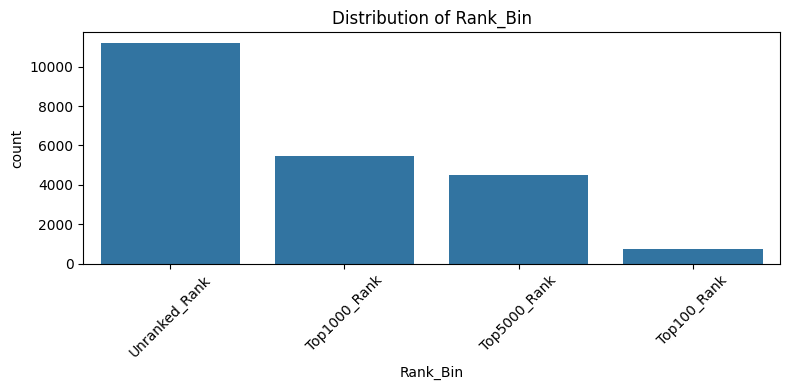

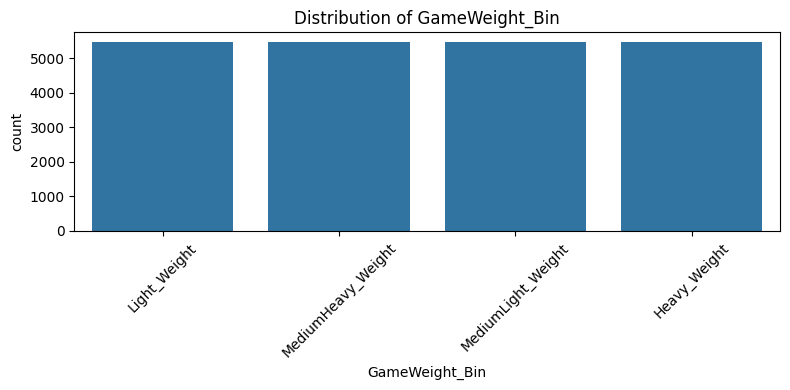

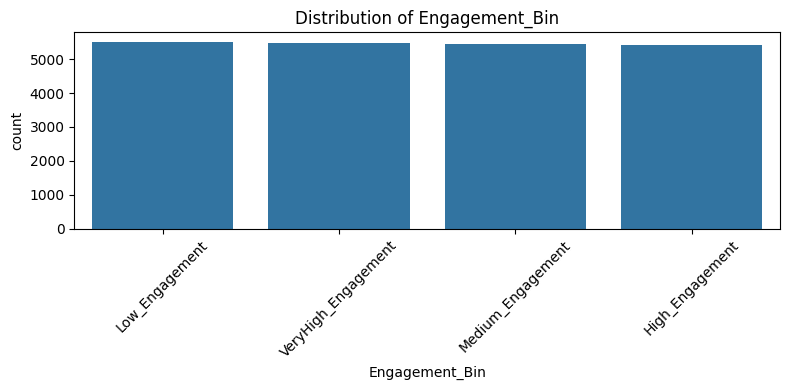

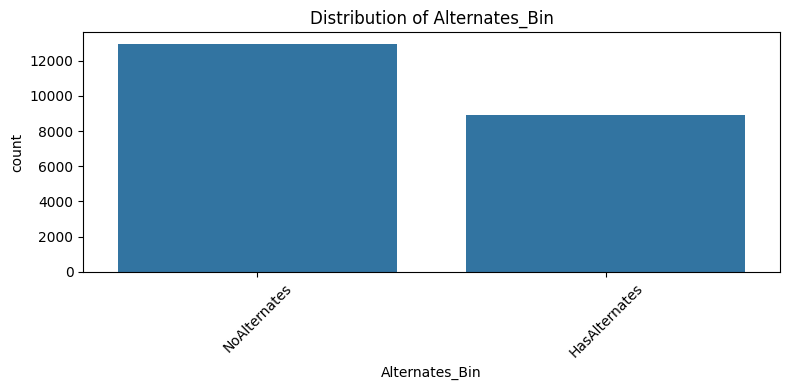

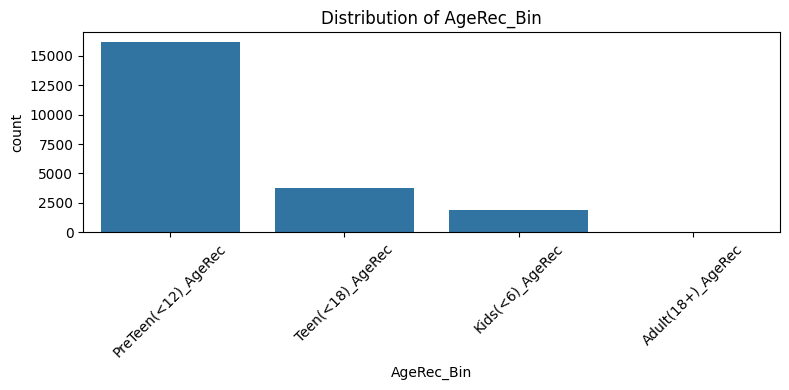

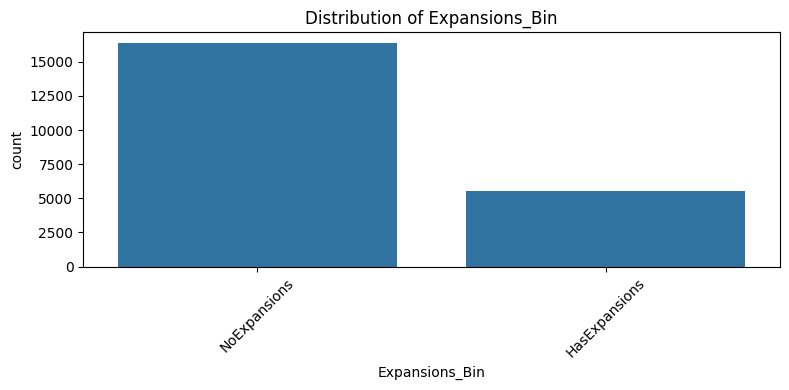

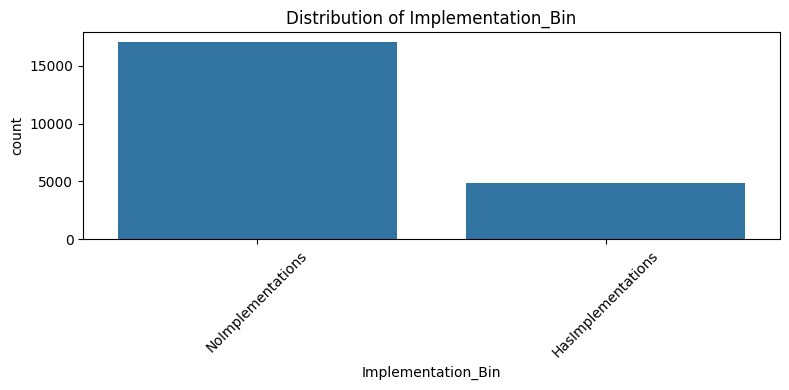

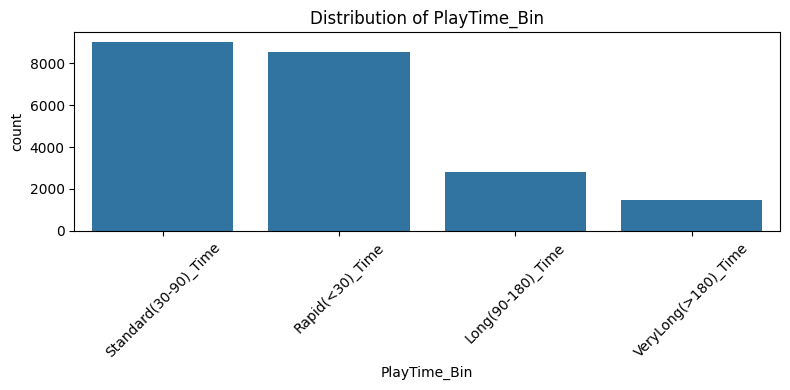

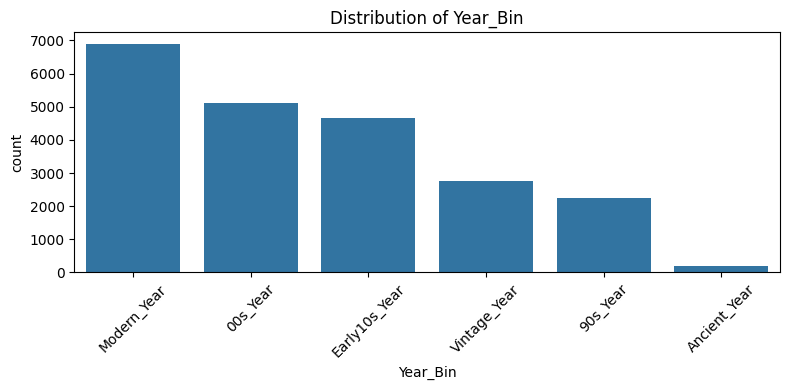

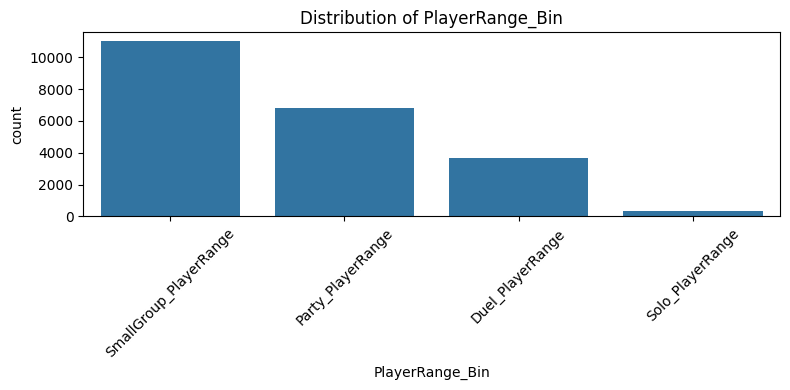

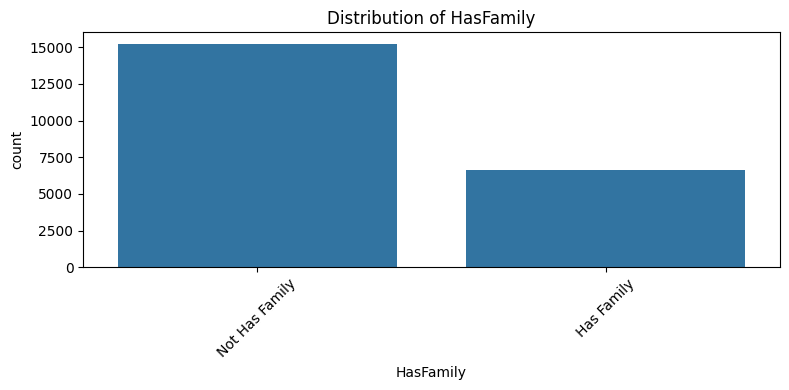

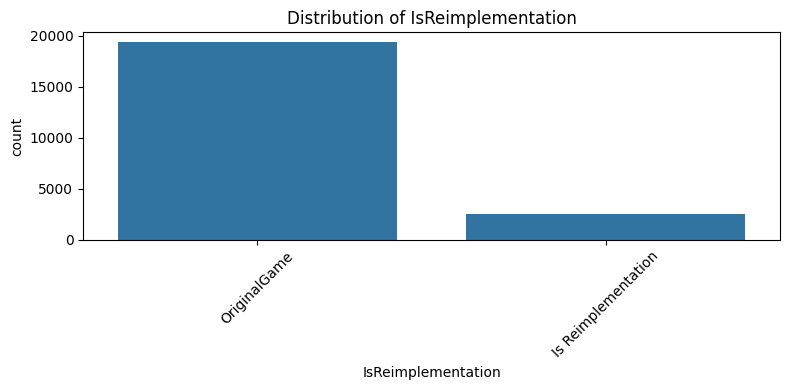

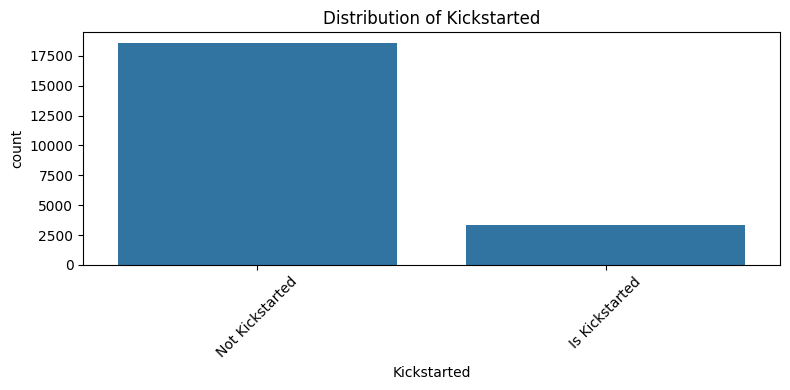

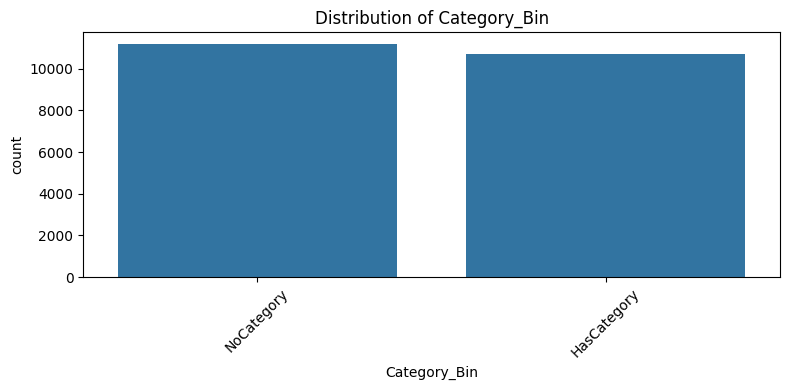

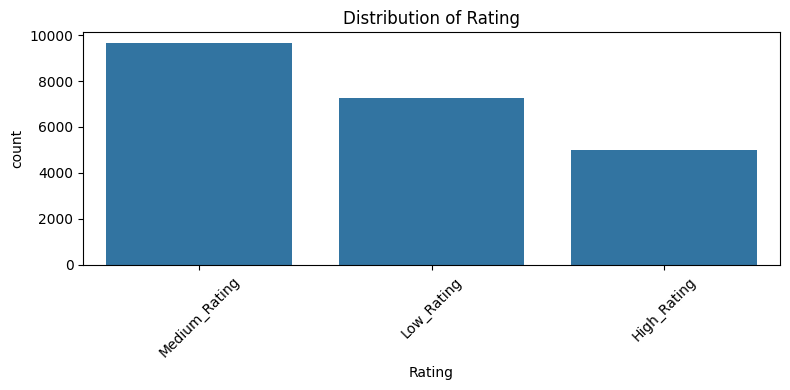

Number of records with NaN Year_Bin: 0
Number of records with NaN PlayTime_Bin: 0


In [7]:
# plot distributions of discretized variables
for col in cols_for_mining:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df_mining, x=col, order=df_mining[col].value_counts().index)
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
# count nan_year and nan_Time records
nan_year_count = df_mining[df_mining['Year_Bin']=="nan_Year"].shape[0]
nan_time_count = df_mining[df_mining['PlayTime_Bin']=="nan_Time"].shape[0]
print(f'Number of records with NaN Year_Bin: {nan_year_count}')
print(f'Number of records with NaN PlayTime_Bin: {nan_time_count}')

In [8]:
X = df_mining.values.tolist()

In [9]:
X[0]

['Unranked_Rank',
 'MediumLight_Weight',
 'High_Engagement',
 'NoAlternates',
 'Teen(<18)_AgeRec',
 'HasExpansions',
 'NoImplementations',
 'Rapid(<30)_Time',
 'Early10s_Year',
 'SmallGroup_PlayerRange',
 'Not Has Family',
 'OriginalGame',
 'Not Kickstarted',
 'NoCategory',
 'Low_Rating']

# Apriori
- frequent itemset >= min_supp

- closed: an itemset is closed if none of its immediate supersets has the same support as the itemset

- maximal: an itemset is maximal frequent if none of its immediate supersets is frequent

## 1. Frequent Itemset

In [410]:
# voglio regole che valgano per almeno il tot% di transazioni (o record, in questo caso)
# supp = 2  # 2%
supp = 10  # 10% (threshold più alto per ridurre il numero di itemset) -> numero di volte in cui compare la tranzasione X/tutte le transazioni
zmin = 2  # minimum number of items per item set

itemsets = apriori(X, target="s", supp=supp, zmin=zmin, report="S") # report="S" means report only support  
pd.DataFrame(itemsets, columns=["frequent_itemset", "support"])

,frequent_itemset,support
0,"(90s_Year, Not Kickstarted)",10.196993
1,"(2_MinPlayers, Not Kickstarted)",10.169569
2,"(2_MinPlayers, OriginalGame)",10.014169
3,"(Is Reimplementation, HasImplementations)",11.563600
4,"(Is Reimplementation, Not Kickstarted, HasImplementations)",10.014169
...,...,...
4125,"(NoExpansions, OriginalGame)",67.055167
4126,"(NoImplementations, OriginalGame)",77.928607
4127,"(NoImplementations, Not Kickstarted, OriginalGame)",65.478313
4128,"(NoImplementations, Not Kickstarted)",65.478313


In [411]:
# return only top 10 itemsets by support
pd.DataFrame(itemsets, columns=["frequent_itemset", "support"]).sort_values(by="support", ascending=False).head(20)

,frequent_itemset,support
4126,"(NoImplementations, OriginalGame)",77.928607
4129,"(Not Kickstarted, OriginalGame)",74.724622
4123,"(NoExpansions, Not Kickstarted)",67.402532
4125,"(NoExpansions, OriginalGame)",67.055167
4128,"(NoImplementations, Not Kickstarted)",65.478313
4127,"(NoImplementations, Not Kickstarted, OriginalGame)",65.478313
4118,"(Not Has Family, OriginalGame)",64.189405
4103,"(1_MinPlayers, OriginalGame)",60.939714
4120,"(NoExpansions, NoImplementations)",60.505508
4119,"(NoExpansions, NoImplementations, OriginalGame)",60.505508


## 2. Closed Itemset

In [412]:
# supp = 2  # 2%
supp = 10  # 10%
zmin = 2  # minimum number of items per item set

itemsets = apriori(X, target="c", supp=supp, zmin=zmin, report="S")
pd.DataFrame(itemsets, columns=["closed_itemset", "support"])

,closed_itemset,support
0,"(90s_Year, Not Kickstarted)",10.196993
1,"(2_MinPlayers, Not Kickstarted)",10.169569
2,"(2_MinPlayers, OriginalGame)",10.014169
3,"(Is Reimplementation, HasImplementations)",11.563600
4,"(Is Reimplementation, HasImplementations, Not Kickstarted)",10.014169
...,...,...
2219,"(NoExpansions, Not Kickstarted, OriginalGame)",60.491796
2220,"(NoExpansions, OriginalGame)",67.055167
2221,"(NoImplementations, Not Kickstarted, OriginalGame)",65.478313
2222,"(NoImplementations, OriginalGame)",77.928607


In [413]:
# return only top 20 closed itemsets by support -> useful to find longest itemsets
pd.DataFrame(itemsets, columns=["closed_itemset", "support"]).sort_values(by="support", ascending=False).head(20)

,closed_itemset,support
2222,"(NoImplementations, OriginalGame)",77.928607
2223,"(Not Kickstarted, OriginalGame)",74.724622
2218,"(NoExpansions, Not Kickstarted)",67.402532
2220,"(NoExpansions, OriginalGame)",67.055167
2221,"(NoImplementations, Not Kickstarted, OriginalGame)",65.478313
2215,"(Not Has Family, OriginalGame)",64.189405
2204,"(1_MinPlayers, OriginalGame)",60.939714
2217,"(NoExpansions, NoImplementations, OriginalGame)",60.505508
2219,"(NoExpansions, Not Kickstarted, OriginalGame)",60.491796
2202,"(1_MinPlayers, Not Kickstarted)",59.893048


## 3. Maximal Itemset

In [414]:
itemsets = apriori(X, target="m", supp=supp, zmin=zmin, report="S")
pd.DataFrame(itemsets, columns=["maximal_itemset", "support"])

,maximal_itemset,support
0,"(90s_Year, Not Kickstarted)",10.196993
1,"(2_MinPlayers, Not Kickstarted)",10.169569
2,"(2_MinPlayers, OriginalGame)",10.014169
3,"(Is Reimplementation, HasImplementations, Not Kickstarted)",10.014169
4,"(Vintage_Year, 1_MinPlayers, Not Kickstarted)",10.037022
...,...,...
486,"(HasCategory, NoAlternates, Not Has Family, NoExpansions, NoImplementations, OriginalGame)",10.169569
487,"(HasCategory, NoAlternates, Not Has Family, NoExpansions, Not Kickstarted, OriginalGame)",10.580922
488,"(HasCategory, NoAlternates, Not Has Family, NoImplementations, Not Kickstarted, OriginalGame)",11.129393
489,"(HasCategory, 1_MinPlayers, Not Has Family, NoExpansions, NoImplementations, Not Kickstarted, OriginalGame)",12.738242


In [415]:
# return top 20 maximal itemsets by support -> useful to find most general patterns
pd.DataFrame(itemsets, columns=["maximal_itemset", "support"]).sort_values(by="support", ascending=False).head(20)

,maximal_itemset,support
359,"(Low_Rating, 1_MinPlayers, Not Has Family, NoExpansions, NoImplementations, Not Kickstarted, OriginalGame)",14.566479
402,"(Rapid(<30)_Time, 1_MinPlayers, Not Has Family, NoExpansions, NoImplementations, Not Kickstarted, OriginalGame)",13.762055
295,"(Has Family, NoExpansions, NoImplementations, Not Kickstarted, OriginalGame)",13.606655
43,"(HasImplementations, 1_MinPlayers, Not Kickstarted)",13.364413
13,"(0_MinPlayers, NoImplementations, OriginalGame)",13.327849
45,"(HasImplementations, NoExpansions, Not Kickstarted)",13.067325
219,"(Light_Weight, Not Has Family, NoExpansions, NoImplementations, Not Kickstarted, OriginalGame)",12.838795
489,"(HasCategory, 1_MinPlayers, Not Has Family, NoExpansions, NoImplementations, Not Kickstarted, OriginalGame)",12.738242
272,"(HasExpansions, HasCategory, OriginalGame)",12.605695
242,"(MediumHeavy_Weight, NoExpansions, NoImplementations, Not Kickstarted, OriginalGame)",12.578271


## Support Plot

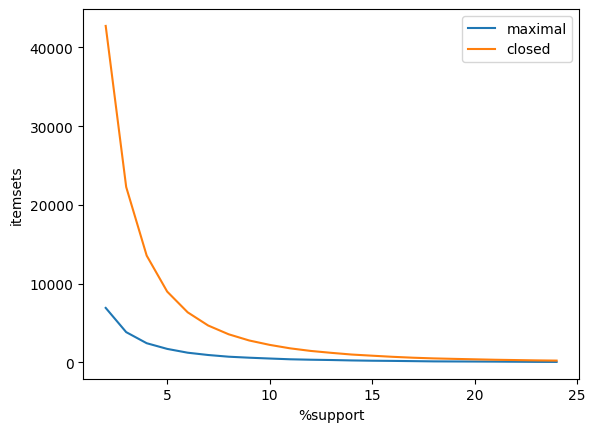

In [416]:
# Variazione del numero di itemset (maximal e closed) in funzione del supporto minimo
len_max_it = []
len_cl_it = []
max_supp = 25
for i in range(2, max_supp):
    max_itemsets = apriori(X, target="m", supp=i, zmin=zmin)
    cl_itemsets = apriori(X, target="c", supp=i, zmin=zmin)
    len_max_it.append(len(max_itemsets))
    len_cl_it.append(len(cl_itemsets))

plt.plot(np.arange(2, max_supp), len_max_it, label="maximal")
plt.plot(np.arange(2, max_supp), len_cl_it, label="closed")
plt.legend()
plt.xlabel("%support")
plt.ylabel("itemsets")

plt.show()

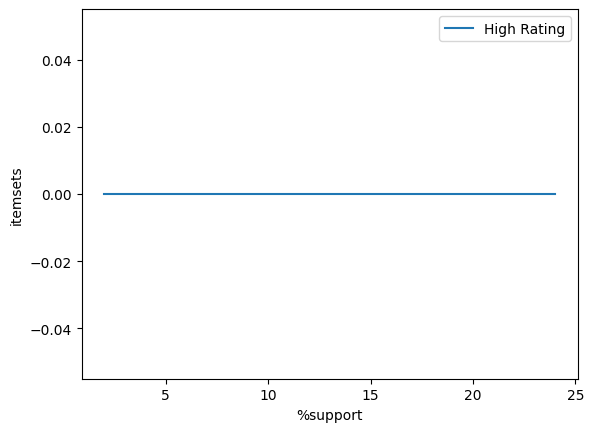

In [417]:
# Variazione del numero di itemset (maximal) contenenti "Survived" o "Not Survived" in funzione del supporto minimo
filter_1 = []
filter_2 = []
max_supp = 25
for i in range(2, max_supp):
    max_itemsets = apriori(X, target="m", supp=i, zmin=zmin)
    filter_1.append(len([item for item in max_itemsets if "High Rating" in item[0]]))
#   filter_2.append(len([item for item in max_itemsets if "Not High Rating" in item[0]]))

plt.plot(np.arange(2, max_supp), filter_1, label="High Rating")
# plt.plot(np.arange(2, max_supp), filter_2, label="Not High Rating")
plt.legend()
plt.xticks()
plt.xlabel("%support")
plt.ylabel("itemsets")

plt.show()

## 4. Rules

In [418]:
conf = 50 # minimum confidence in %
rules = apriori(X, target="r", supp=supp, zmin=zmin, conf=conf, report="aScl") # report antecedent, support, confidence, lift
rules_df = pd.DataFrame(
    rules,
    columns=[
        "consequent",
        "antecedent",
        "abs_support",
        "%_support",
        "confidence",
        "lift",
    ],
)
rules_df = rules_df[rules_df["lift"] > 1]
rules_df.sort_values(by="lift", axis=0, ascending=False)

,consequent,antecedent,abs_support,%_support,confidence,lift
43,Is Reimplementation,"(HasImplementations, Has Family)",1317,6.019471,0.591113,5.111843
49,Is Reimplementation,"(HasImplementations, NoAlternates)",1360,6.216006,0.558751,4.831982
57,Is Reimplementation,"(HasImplementations, NoExpansions)",1664,7.605466,0.537294,4.646426
55,Is Reimplementation,"(HasImplementations, NoExpansions, Not Kickstarted)",1512,6.910736,0.528856,4.573457
62,Is Reimplementation,"(HasImplementations,)",2530,11.563600,0.523918,4.530752
...,...,...,...,...,...,...
25197,1_MinPlayers,"(Unranked_Rank, Not Has Family, NoExpansions, Not Kickstarted, OriginalGame)",3879,17.729329,0.687035,1.000043
24561,1_MinPlayers,"(Unranked_Rank, NoCategory, Not Has Family, NoExpansions, Not Kickstarted, OriginalGame)",3879,17.729329,0.687035,1.000043
5021,1_MinPlayers,"(VeryHigh_Engagement, HasCategory, NoExpansions)",1620,7.404360,0.687023,1.000025
5032,Not Kickstarted,"(VeryHigh_Engagement, HasCategory, 1_MinPlayers, OriginalGame)",2099,9.593674,0.847396,1.000010


In [419]:
# return top 20 rules by lift
pd.DataFrame(rules, columns=["consequent", "antecedent", "abs_support", "%_support", "confidence", "lift"]).sort_values(by="lift", ascending=False).head(20)

# enlarge width of displayed dataframe
pd.set_option('display.max_colwidth', None)
pd.DataFrame(rules, columns=["consequent", "antecedent", "abs_support", "%_support", "confidence", "lift"]).sort_values(by="lift", ascending=False).head(40)



,consequent,antecedent,abs_support,%_support,confidence,lift
43,Is Reimplementation,"(HasImplementations, Has Family)",1317,6.019471,0.591113,5.111843
49,Is Reimplementation,"(HasImplementations, NoAlternates)",1360,6.216006,0.558751,4.831982
57,Is Reimplementation,"(HasImplementations, NoExpansions)",1664,7.605466,0.537294,4.646426
55,Is Reimplementation,"(HasImplementations, NoExpansions, Not Kickstarted)",1512,6.910736,0.528856,4.573457
62,Is Reimplementation,"(HasImplementations,)",2530,11.563600,0.523918,4.530752
61,HasImplementations,"(Is Reimplementation,)",2530,11.563600,1.000000,4.530752
59,HasImplementations,"(Is Reimplementation, Not Kickstarted)",2191,10.014169,1.000000,4.530752
53,Is Reimplementation,"(HasImplementations, 1_MinPlayers)",1698,7.760867,0.521339,4.508446
51,Is Reimplementation,"(HasImplementations, 1_MinPlayers, Not Kickstarted)",1522,6.956442,0.520520,4.501365
60,Is Reimplementation,"(HasImplementations, Not Kickstarted)",2191,10.014169,0.519934,4.496295


In [420]:
rules_df[rules_df["consequent"] == "VeryHigh_Engagement"].sort_values(by="lift", ascending=False)


,consequent,antecedent,abs_support,%_support,confidence,lift
4769,VeryHigh_Engagement,"(HasExpansions, HasAlternates)",1675,7.655743,0.711555,2.846610
4797,VeryHigh_Engagement,"(Has Family, HasAlternates, HasCategory)",1538,7.029572,0.689686,2.759123
4786,VeryHigh_Engagement,"(HasExpansions, HasCategory)",2259,10.324969,0.677971,2.712257
4784,VeryHigh_Engagement,"(HasExpansions, HasCategory, OriginalGame)",1849,8.451026,0.670413,2.682021
4781,VeryHigh_Engagement,"(HasExpansions, HasCategory, Not Kickstarted)",1609,7.354084,0.649314,2.597612
4820,VeryHigh_Engagement,"(HasAlternates, Medium_Rating, HasCategory)",1516,6.929019,0.638854,2.555766
2725,VeryHigh_Engagement,"(Top1000_Rank, Medium_Rating, HasCategory)",1536,7.020431,0.634449,2.538142
2732,VeryHigh_Engagement,"(Top1000_Rank, Medium_Rating)",1536,7.020431,0.634449,2.538142
4778,VeryHigh_Engagement,"(HasExpansions, HasCategory, 1_MinPlayers)",1415,6.467389,0.633393,2.533920
2704,VeryHigh_Engagement,"(Top1000_Rank, HasAlternates, HasCategory)",1963,8.972074,0.624364,2.497798


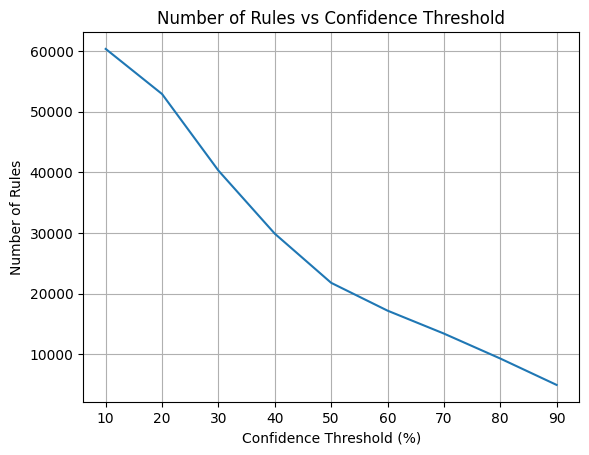

In [421]:
# number of rules with varying confidence thresholds
conf_levels = range(10, 100, 10)
num_rules_per_conf = []
for conf in conf_levels:
    rules = apriori(X, target="r", supp=supp, zmin=zmin, conf=conf, report="aScl")
    rules_df = pd.DataFrame(
        rules,
        columns=[
            "consequent",
            "antecedent",
            "abs_support",
            "%_support",
            "confidence",
            "lift",
        ],
    )
    rules_df = rules_df[rules_df["lift"] > 1]
    num_rules_per_conf.append(len(rules_df))
plt.plot(conf_levels, num_rules_per_conf, marker=None)
plt.xlabel("Confidence Threshold (%)")
plt.ylabel("Number of Rules")
plt.title("Number of Rules vs Confidence Threshold")
plt.xticks(conf_levels)
plt.grid()
plt.show()


## 5. Classification

Default Class: Low_Engagement
Esecuzione Apriori...
Regole totali ibride: 386
Regole usate per il voto: 386
Inizio predizione (Voting)...
------------------------------
F1-Score (Weighted): 0.4025
Copertura Regole: 100.00%

--- Classification Report ---
                     precision    recall  f1-score   support

    High_Engagement       0.43      0.17      0.24      1662
     Low_Engagement       0.42      0.48      0.45      1613
  Medium_Engagement       0.34      0.29      0.31      1658
VeryHigh_Engagement       0.49      0.81      0.61      1631

           accuracy                           0.43      6564
          macro avg       0.42      0.44      0.40      6564
       weighted avg       0.42      0.43      0.40      6564


--- Confusion Matrix ---
[[ 778  451   80  304]
 [ 590  480  157  431]
 [ 395  365  276  626]
 [  83  100  130 1318]]


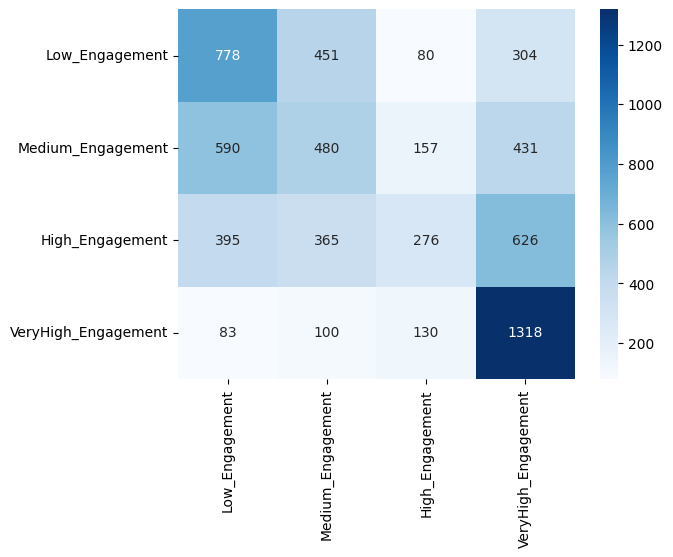

In [422]:
from collections import Counter
from sklearn.metrics import f1_score, classification_report, confusion_matrix

# --- 1. PREPARAZIONE ---
# X deve essere una lista di liste (transazioni)
target_classes = {"Low_Engagement", "Medium_Engagement", "High_Engagement", "VeryHigh_Engagement"}

x_train, x_test = train_test_split(X, test_size=0.3, random_state=0)

# Calcoliamo la Default Class (Majority Class)
train_labels = [next((item for item in rec if item in target_classes), None) for rec in x_train]
default_class = Counter(train_labels).most_common(1)[0][0]
print(f"Default Class: {default_class}")


# --- 2. MINING E PRUNING INTELLIGENTE ---
print("Esecuzione Apriori...")
# Usiamo zmin=2 per evitare regole vuote o banali
rules_raw = apriori(x_train, target="r", supp=supp, zmin=2, conf=20, report="aScl") 

rules_df = pd.DataFrame(
    rules_raw,
    columns=["consequent", "antecedent", "abs_supp", "%_supp", "conf", "lift"]
)

# Filtriamo solo le regole che predicono il target
rules_df = rules_df[rules_df["consequent"].isin(target_classes) & (rules_df["lift"] > 1)]

# 1. Calcoliamo le Top per LIFT (Qualità)
top_lift = rules_df.sort_values(by="lift", ascending=False).groupby("consequent").head(50)

# 2. Calcoliamo le Top per SUPPORT (Quantità/Copertura)
top_supp = rules_df.sort_values(by="%_supp", ascending=False).groupby("consequent").head(50)

# 3. Uniamo i due set e rimuoviamo duplicati
# (Usiamo l'ID della regola o resettiamo l'indice per unire)
combined_rules = pd.concat([top_lift, top_supp]).drop_duplicates(subset=["consequent", "antecedent"])

print(f"Regole totali ibride: {len(combined_rules)}")


rules_pruned = combined_rules

voting_rules = []
for _, row in rules_pruned.iterrows():
    voting_rules.append({
        "consequent": row["consequent"],
        "antecedent": set(row["antecedent"]),
        "lift": row["lift"],   # Il "peso" del voto
        "conf": row["conf"]    # Alternativa: usare confidenza
    })

print(f"Regole usate per il voto: {len(voting_rules)}")

# --- 2. FUNZIONE DI PREDIZIONE (WEIGHTED VOTING) ---

def predict_voting(record, rules, default_class):
    record_set = set(record)
    
    # Inizializziamo i punteggi per ogni classe a 0
    # Assicurati che score_board contenga tutte le tue classi
    score_board = {cls: 0 for cls in target_classes}
    
    rules_triggered = 0
    
    for rule in rules:
        # Se la regola si applica al record
        if rule["antecedent"].issubset(record_set):
            # Aggiungiamo il Lift al punteggio della classe predetta
            # (Puoi provare anche rule["conf"] o rule["lift"] * rule["conf"])
            score_board[rule["consequent"]] += rule["lift"]
            rules_triggered += 1
            
    # Se nessuna regola si è attivata, usiamo il default
    if rules_triggered == 0:
        return default_class
    
    # Restituiamo la classe con il punteggio più alto
    return max(score_board, key=score_board.get)

# --- 3. VALUTAZIONE ---
correct = 0
total = 0
uncovered_count = 0

# --- LISTE PER SALVARE I RISULTATI ---
y_true = []
y_pred = []

# Variabili per statistiche interne (opzionale)
uncovered_count = 0 

print("Inizio predizione (Voting)...")

for record in x_test:
    # 1. Estrazione Ground Truth
    true_label = next((item for item in record if item in target_classes), None)
    
    # 2. Pulizia record per il test
    record_features = [item for item in record if item not in target_classes]
    
    if true_label:
        # Eseguiamo la predizione
        prediction = predict_voting(record_features, voting_rules, default_class)
        
        # Salviamo nelle liste per sklearn
        y_true.append(true_label)
        y_pred.append(prediction)
        
        # Controllo di copertura (se nessuna regola si è attivata)
        matches_any = any(rule["antecedent"].issubset(set(record_features)) for rule in voting_rules)
        if not matches_any:
            uncovered_count += 1

# --- CALCOLO METRICHE ---

# 1. F1 Score Globale (Weighted è meglio se le classi sono sbilanciate)
f1 = f1_score(y_true, y_pred, average='weighted')

print("-" * 30)
print(f"F1-Score (Weighted): {f1:.4f}")
print(f"Copertura Regole: {((len(y_true) - uncovered_count) / len(y_true))*100:.2f}%")

# 2. Report Dettagliato (F1 per ogni classe)
print("\n--- Classification Report ---")
print(classification_report(y_true, y_pred))

# 3. Matrice di Confusione (Opzionale ma utilissima per capire gli errori)
# Ti mostra se il modello confonde classi vicine (es. High vs VeryHigh)
cm = confusion_matrix(y_true, y_pred, labels=list(target_classes))
print("\n--- Confusion Matrix ---")
#heatmap per visualizzare meglio
sns.heatmap(cm, annot=True, fmt='d', xticklabels=target_classes, yticklabels=target_classes, cmap='Blues')
print(cm)

# FP-Growth

In [12]:
zmin = 2
len_r = []
min_sup = 1
max_sup = 20
min_conf = 50
max_conf = 90
for i in range(min_sup, max_sup):  # support
    len_r_wrt_i = []
    for j in range(min_conf, max_conf, 5):  # confidence
        rules = fpgrowth(X, target="r", supp=i, zmin=zmin, conf=j, report="aScl")
        len_r_wrt_i.append(len(rules))  # study your characteristics/properties here

    len_r.append(len_r_wrt_i)
len_r = np.array(len_r)

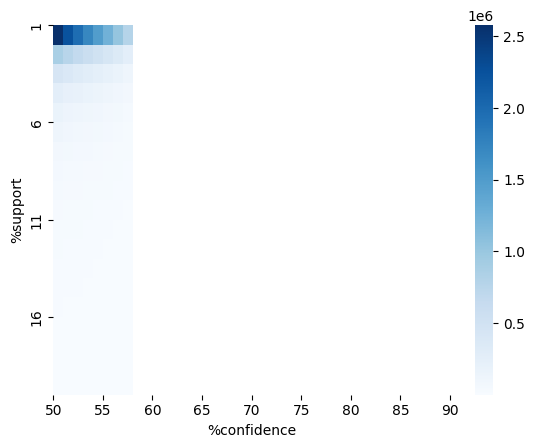

In [13]:
sns.heatmap(len_r, cmap="Blues", fmt='g')
plt.yticks(np.arange(0, max_sup-min_sup +1, 5), np.arange(min_sup, max_sup+1,5 ))
plt.xticks(np.arange(0, max_conf-min_conf+1, 5), np.arange(min_conf, max_conf+1, 5))
plt.xlabel("%confidence")
plt.ylabel("%support")
plt.show()

### Choosing min_supp 

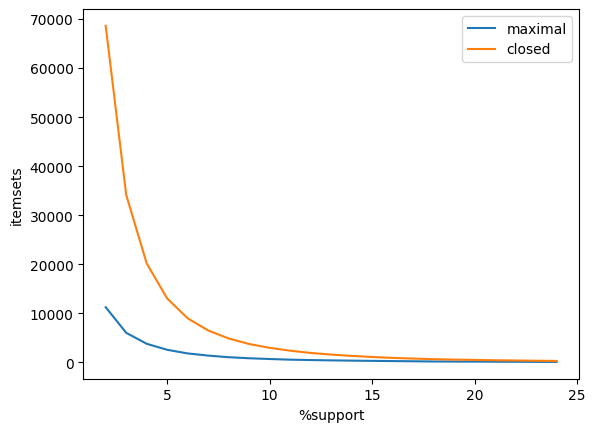

In [112]:
zmin = 2  # minimum number of items per item set

# Variazione del numero di itemset (maximal e closed) in funzione del supporto minimo
len_max_it = []
len_cl_it = []
max_supp = 25
for i in range(2, max_supp):
    max_itemsets = fpgrowth(X, target="m", supp=i, zmin=zmin)
    cl_itemsets = fpgrowth(X, target="c", supp=i, zmin=zmin)
    len_max_it.append(len(max_itemsets))
    len_cl_it.append(len(cl_itemsets))

plt.plot(np.arange(2, max_supp), len_max_it, label="maximal")
plt.plot(np.arange(2, max_supp), len_cl_it, label="closed")
plt.legend()
plt.xlabel("%support")
plt.ylabel("itemsets")

plt.show()

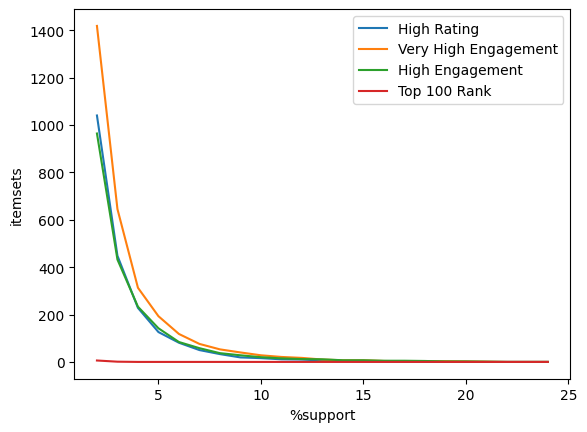

In [113]:
# Variazione del numero di itemset (maximal) contenenti "High Rating" o "Very High Engagement" in funzione del supporto minimo
filter_1 = []
filter_2 = []
filter_3 = []
filter_4 = []
max_supp = 25
for i in range(2, max_supp):
    max_itemsets = fpgrowth(X, target="m", supp=i, zmin=zmin)
    filter_1.append(len([item for item in max_itemsets if "High_Rating" in item[0]]))
    filter_2.append(len([item for item in max_itemsets if "VeryHigh_Engagement" in item[0]]))
    filter_3.append(len([item for item in max_itemsets if "High_Engagement" in item[0]]))
    filter_4.append(len([item for item in max_itemsets if "Top100_Rank" in item[0]]))

plt.plot(np.arange(2, max_supp), filter_1, label="High Rating")
plt.plot(np.arange(2, max_supp), filter_2, label="Very High Engagement")
plt.plot(np.arange(2, max_supp), filter_3, label="High Engagement")
plt.plot(np.arange(2, max_supp), filter_4, label="Top 100 Rank")
plt.legend()
plt.xticks()
plt.xlabel("%support")
plt.ylabel("itemsets")

plt.show()

### Frequent Itemsets

In [119]:
# prendo un support = 5-7 come suggerito dal grafico
supp = 10 # 10%

itemsets = fpgrowth(X, target="s", supp=supp, zmin=zmin, report="S")
pd.DataFrame(itemsets, columns=["frequent_itemset", "support"])

,frequent_itemset,support
0,"(Not Kickstarted, OriginalGame)",74.724622
1,"(NoImplementations, Not Kickstarted, OriginalGame)",65.478313
2,"(NoImplementations, Not Kickstarted)",65.478313
3,"(NoImplementations, OriginalGame)",77.928607
4,"(NoExpansions, OriginalGame)",67.055167
...,...,...
5460,"(Vintage_Year, PreTeen(<12)_AgeRec)",10.882581
5461,"(Is Reimplementation, Not Kickstarted, HasImplementations)",10.014169
5462,"(Is Reimplementation, Not Kickstarted)",10.014169
5463,"(Is Reimplementation, HasImplementations)",11.563600


### Maximal Itemsets

In [120]:
maximal_itemsets = fpgrowth(X, target="m", supp=supp, zmin=zmin, report="S")
print(f"Number of maximal itemsets found: {len(maximal_itemsets)}")
pd.set_option('display.max_colwidth', None)
pd.DataFrame(maximal_itemsets, columns=["maximal_itemset", "%support"]).sort_values(by="%support", ascending=False).head(20)

Number of maximal itemsets found: 670


,maximal_itemset,%support
668,"(SmallGroup_PlayerRange, Not Has Family, PreTeen(<12)_AgeRec, NoExpansions, NoImplementations, Not Kickstarted, OriginalGame)",15.430321
459,"(Low_Rating, Not Has Family, PreTeen(<12)_AgeRec, NoExpansions, NoImplementations, Not Kickstarted, OriginalGame)",14.433932
635,"(Medium_Rating, Not Has Family, PreTeen(<12)_AgeRec, NoExpansions, NoImplementations, Not Kickstarted, OriginalGame)",13.661502
21,"(Teen(<18)_AgeRec, NoImplementations, OriginalGame)",13.624937
511,"(Rapid(<30)_Time, Not Has Family, PreTeen(<12)_AgeRec, NoExpansions, NoImplementations, Not Kickstarted, OriginalGame)",13.318707
651,"(HasCategory, Not Has Family, PreTeen(<12)_AgeRec, NoExpansions, NoImplementations, Not Kickstarted, OriginalGame)",13.126743
590,"(Standard(30-90)_Time, Not Has Family, PreTeen(<12)_AgeRec, NoExpansions, NoImplementations, Not Kickstarted, OriginalGame)",13.094748
382,"(Party_PlayerRange, PreTeen(<12)_AgeRec, NoExpansions, NoImplementations, Not Kickstarted, OriginalGame)",13.044472
381,"(Party_PlayerRange, Not Has Family, NoExpansions, NoImplementations, Not Kickstarted, OriginalGame)",12.898213
258,"(Light_Weight, Not Has Family, NoExpansions, NoImplementations, Not Kickstarted, OriginalGame)",12.838795


In [121]:
# maximal itemsets contenenti "High Rating"
filtered_maximal = [item for item in maximal_itemsets if "High_Rating" in item[0]]
pd.set_option('display.max_colwidth', None)
pd.DataFrame(filtered_maximal, columns=["maximal_itemset", "%support"]).sort_values(by="%support", ascending=False)

,maximal_itemset,%support
0,"(High_Rating, Heavy_Weight)",11.961241
15,"(High_Rating, NoImplementations, Not Kickstarted, OriginalGame)",11.348782
6,"(High_Rating, HasCategory, OriginalGame)",11.257370
5,"(High_Rating, HasCategory, Not Kickstarted)",11.106541
11,"(High_Rating, PreTeen(<12)_AgeRec, NoImplementations, OriginalGame)",10.772887
8,"(High_Rating, NoAlternates, NoImplementations, OriginalGame)",10.658622
7,"(High_Rating, SmallGroup_PlayerRange, OriginalGame)",10.516934
1,"(High_Rating, HasExpansions)",10.475799
4,"(High_Rating, Standard(30-90)_Time)",10.452946
14,"(High_Rating, NoExpansions, OriginalGame)",10.388957


In [122]:
# maximal itemsets contenenti "Very High Engagement"
filtered_maximal = [item for item in maximal_itemsets if "VeryHigh_Engagement" in item[0]]
pd.set_option('display.max_colwidth', None)
pd.DataFrame(filtered_maximal, columns=["maximal_itemset", "%support"]).sort_values(by="%support", ascending=False)

,maximal_itemset,%support
6,"(VeryHigh_Engagement, HasAlternates, HasCategory, Not Kickstarted)",11.778418
26,"(VeryHigh_Engagement, NoExpansions, Not Kickstarted)",11.527035
22,"(VeryHigh_Engagement, SmallGroup_PlayerRange, Not Kickstarted)",11.293935
4,"(VeryHigh_Engagement, Has Family)",11.289364
7,"(VeryHigh_Engagement, HasAlternates, HasCategory, OriginalGame)",11.271082
25,"(VeryHigh_Engagement, PreTeen(<12)_AgeRec, NoImplementations, OriginalGame)",11.143105
1,"(Top1000_Rank, VeryHigh_Engagement, OriginalGame, HasCategory)",11.028840
0,"(Top1000_Rank, VeryHigh_Engagement, Not Kickstarted, HasCategory)",10.900864
9,"(VeryHigh_Engagement, HasAlternates, Not Kickstarted, OriginalGame)",10.887152
18,"(VeryHigh_Engagement, HasCategory, NoExpansions)",10.777458


In [123]:
# maximal itemsets contenenti "Top100_Rank"
filtered_maximal = [item for item in maximal_itemsets if "Top1000_Rank" in item[0]]
pd.set_option('display.max_colwidth', None)
pd.DataFrame(filtered_maximal, columns=["maximal_itemset", "%support"]).sort_values(by="%support", ascending=False)

,maximal_itemset,%support
11,"(Top1000_Rank, Not Has Family, Not Kickstarted, OriginalGame, HasCategory)",11.760135
10,"(Top1000_Rank, Not Has Family, NoImplementations, HasCategory, OriginalGame)",11.444764
14,"(Top1000_Rank, NoExpansions, NoImplementations, Not Kickstarted, HasCategory, OriginalGame)",11.074546
4,"(Top1000_Rank, Medium_Rating, HasCategory)",11.065405
1,"(Top1000_Rank, VeryHigh_Engagement, OriginalGame, HasCategory)",11.028840
6,"(Top1000_Rank, SmallGroup_PlayerRange, OriginalGame, HasCategory)",10.960282
0,"(Top1000_Rank, VeryHigh_Engagement, Not Kickstarted, HasCategory)",10.900864
12,"(Top1000_Rank, PreTeen(<12)_AgeRec, NoExpansions, Not Kickstarted, HasCategory)",10.855158
3,"(Top1000_Rank, HasAlternates, Not Kickstarted, OriginalGame, HasCategory)",10.841446
5,"(Top1000_Rank, SmallGroup_PlayerRange, Not Kickstarted, HasCategory)",10.672334


### Closed Itemsets

In [124]:
closed_itemsets = fpgrowth(X, target="c", supp=supp, zmin=zmin, report="S")
pd.DataFrame(closed_itemsets, columns=["closed_itemset", "%support"]).sort_values(by="%support", ascending=False).head(20)

,closed_itemset,%support
2949,"(NoImplementations, OriginalGame)",77.928607
2950,"(Not Kickstarted, OriginalGame)",74.724622
2946,"(NoExpansions, Not Kickstarted)",67.402532
2947,"(NoExpansions, OriginalGame)",67.055167
2948,"(NoImplementations, Not Kickstarted, OriginalGame)",65.478313
2942,"(PreTeen(<12)_AgeRec, OriginalGame)",65.473742
2941,"(PreTeen(<12)_AgeRec, Not Kickstarted)",65.144659
2931,"(Not Has Family, OriginalGame)",64.189405
2944,"(NoExpansions, NoImplementations, OriginalGame)",60.505508
2945,"(NoExpansions, Not Kickstarted, OriginalGame)",60.491796


### Rule Generation

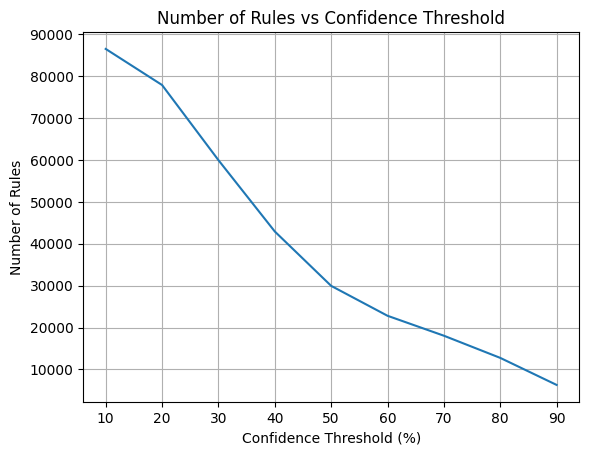

In [125]:
# number of rules with varying confidence thresholds
conf_levels = range(10, 100, 10)
num_rules_per_conf = []
for conf in conf_levels:
    rules = fpgrowth(X, target="r", supp=supp, zmin=zmin, conf=conf, report="aScl")
    rules_df = pd.DataFrame(
        rules,
        columns=[
            "consequent",
            "antecedent",
            "abs_support",
            "%_support",
            "confidence",
            "lift",
        ],
    )
    rules_df = rules_df[rules_df["lift"] > 1]
    num_rules_per_conf.append(len(rules_df))
plt.plot(conf_levels, num_rules_per_conf, marker=None)
plt.xlabel("Confidence Threshold (%)")
plt.ylabel("Number of Rules")
plt.title("Number of Rules vs Confidence Threshold")
plt.xticks(conf_levels)
plt.grid()
plt.show()


In [126]:
conf = 50
rules = fpgrowth(X, target="r", supp=supp, zmin=zmin, conf=conf, report="aScl")
rules_df = pd.DataFrame(
    rules,
    columns=[
        "consequent",
        "antecedent",
        "abs_support",
        "%_support",
        "confidence",
        "lift",
    ],
)
print(f"Regole estratte con Confidenza >= {conf}%: {len(rules)}")

Regole estratte con Confidenza >= 50%: 36102


In [127]:
rules_df = rules_df[rules_df["lift"] > 1]
rules_df.sort_values(by="lift", axis=0, ascending=False)

,consequent,antecedent,abs_support,%_support,confidence,lift
36082,Is Reimplementation,"(HasImplementations, Has Family)",1317,6.019471,0.591113,5.111843
36074,Is Reimplementation,"(HasImplementations, NoAlternates)",1360,6.216006,0.558751,4.831982
36076,Is Reimplementation,"(HasImplementations, SmallGroup_PlayerRange)",1271,5.809223,0.553090,4.783023
36065,Is Reimplementation,"(HasImplementations, NoExpansions)",1664,7.605466,0.537294,4.646426
36063,Is Reimplementation,"(HasImplementations, NoExpansions, Not Kickstarted)",1512,6.910736,0.528856,4.573457
...,...,...,...,...,...,...
18447,NoExpansions,"(Modern_Year, NoCategory, Not Has Family, PreTeen(<12)_AgeRec, OriginalGame)",1751,8.003108,0.746695,1.000119
18742,NoExpansions,"(Modern_Year, Unranked_Rank, Not Has Family, PreTeen(<12)_AgeRec, OriginalGame)",1751,8.003108,0.746695,1.000119
28465,OriginalGame,"(MediumLight_Weight, PreTeen(<12)_AgeRec, Not Kickstarted)",3445,15.745692,0.884467,1.000117
2340,NoExpansions,"(SmallGroup_PlayerRange, PreTeen(<12)_AgeRec, OriginalGame)",5155,23.561406,0.746669,1.000083


In [128]:
rules_df[rules_df["consequent"] == "VeryHigh_Engagement"].sort_values(by="lift", ascending=False).head(20)

,consequent,antecedent,abs_support,%_support,confidence,lift
30150,VeryHigh_Engagement,"(HasExpansions, HasAlternates)",1675,7.655743,0.711555,2.846610
30108,VeryHigh_Engagement,"(Has Family, HasAlternates, HasCategory)",1538,7.029572,0.689686,2.759123
30139,VeryHigh_Engagement,"(HasExpansions, HasCategory)",2259,10.324969,0.677971,2.712257
30129,VeryHigh_Engagement,"(HasExpansions, HasCategory, OriginalGame)",1849,8.451026,0.670413,2.682021
30131,VeryHigh_Engagement,"(HasExpansions, HasCategory, Not Kickstarted)",1609,7.354084,0.649314,2.597612
29942,VeryHigh_Engagement,"(Standard(30-90)_Time, HasCategory, SmallGroup_PlayerRange)",1451,6.631930,0.644889,2.579909
30066,VeryHigh_Engagement,"(HasAlternates, HasCategory, SmallGroup_PlayerRange)",1774,8.108232,0.639510,2.558390
30082,VeryHigh_Engagement,"(HasAlternates, Medium_Rating, HasCategory)",1516,6.929019,0.638854,2.555766
32543,VeryHigh_Engagement,"(Top1000_Rank, Medium_Rating)",1536,7.020431,0.634449,2.538142
32540,VeryHigh_Engagement,"(Top1000_Rank, Medium_Rating, HasCategory)",1536,7.020431,0.634449,2.538142


In [134]:
rules_df[rules_df["consequent"] == "Low_Engagement"].sort_values(by="lift", ascending=False).head(20)

,consequent,antecedent,abs_supp,%_supp,conf,lift
50010,Low_Engagement,"(Low_Rating, Unranked_Rank, NoAlternates, NoExpansions, Not Kickstarted, OriginalGame)",822,5.367287,0.536204,2.102934
49840,Low_Engagement,"(Low_Rating, NoCategory, NoAlternates, NoExpansions, Not Kickstarted, OriginalGame)",822,5.367287,0.536204,2.102934
50154,Low_Engagement,"(Low_Rating, Unranked_Rank, NoCategory, NoAlternates, NoExpansions, Not Kickstarted, OriginalGame)",822,5.367287,0.536204,2.102934
50155,Low_Engagement,"(Low_Rating, Unranked_Rank, NoCategory, NoAlternates, NoExpansions, Not Kickstarted)",868,5.667646,0.535142,2.098770
49841,Low_Engagement,"(Low_Rating, NoCategory, NoAlternates, NoExpansions, Not Kickstarted)",868,5.667646,0.535142,2.098770
50011,Low_Engagement,"(Low_Rating, Unranked_Rank, NoAlternates, NoExpansions, Not Kickstarted)",868,5.667646,0.535142,2.098770
49843,Low_Engagement,"(Low_Rating, NoCategory, NoAlternates, NoExpansions, NoImplementations, OriginalGame)",869,5.674176,0.534769,2.097309
50013,Low_Engagement,"(Low_Rating, Unranked_Rank, NoAlternates, NoExpansions, NoImplementations, OriginalGame)",869,5.674176,0.534769,2.097309
50015,Low_Engagement,"(Low_Rating, Unranked_Rank, NoAlternates, NoExpansions, NoImplementations)",869,5.674176,0.534769,2.097309
49845,Low_Engagement,"(Low_Rating, NoCategory, NoAlternates, NoExpansions, NoImplementations)",869,5.674176,0.534769,2.097309


In [130]:
rules_df[rules_df["consequent"] == "High_Rating"].sort_values(by="lift", ascending=False).head(20)

,consequent,antecedent,abs_support,%_support,confidence,lift
34140,High_Rating,"(HasExpansions, Modern_Year)",1343,6.138306,0.566906,2.480667
34177,High_Rating,"(Heavy_Weight, SmallGroup_PlayerRange)",1476,6.746195,0.517532,2.264615
34143,High_Rating,"(HasExpansions, Has Family)",1194,5.457288,0.516883,2.261777
34151,High_Rating,"(VeryHigh_Engagement, HasExpansions)",1357,6.202294,0.505589,2.212355
34149,High_Rating,"(VeryHigh_Engagement, HasExpansions, HasCategory)",1137,5.196764,0.503320,2.202428


In [131]:
rules_df[rules_df["consequent"] == "Low_Rating"].sort_values(by="lift", ascending=False).head(20)

,consequent,antecedent,abs_support,%_support,confidence,lift
27907,Low_Rating,"(Light_Weight, NoExpansions, NoImplementations, Not Kickstarted, OriginalGame)",2356,10.768317,0.659021,1.991261
27911,Low_Rating,"(Light_Weight, NoExpansions, NoImplementations, Not Kickstarted)",2356,10.768317,0.659021,1.991261
27983,Low_Rating,"(Light_Weight, Not Has Family, NoExpansions, NoImplementations, Not Kickstarted, OriginalGame)",1850,8.455597,0.658597,1.989981
27985,Low_Rating,"(Light_Weight, Not Has Family, NoExpansions, NoImplementations, Not Kickstarted)",1850,8.455597,0.658597,1.989981
28179,Low_Rating,"(Light_Weight, HasAlternates, NoExpansions, Not Kickstarted, OriginalGame)",1437,6.567942,0.654372,1.977213
27895,Low_Rating,"(Light_Weight, NoExpansions, Not Kickstarted, OriginalGame)",2623,11.988665,0.651192,1.967604
27975,Low_Rating,"(Light_Weight, Not Has Family, NoExpansions, Not Kickstarted, OriginalGame)",2047,9.356003,0.650048,1.964148
28037,Low_Rating,"(Light_Weight, NoCategory, NoExpansions, NoImplementations, Not Kickstarted)",1630,7.450066,0.647854,1.957519
28089,Low_Rating,"(Light_Weight, Unranked_Rank, NoExpansions, NoImplementations, Not Kickstarted, OriginalGame)",1630,7.450066,0.647854,1.957519
28130,Low_Rating,"(Light_Weight, Unranked_Rank, NoCategory, NoExpansions, NoImplementations, Not Kickstarted)",1630,7.450066,0.647854,1.957519


Default Class: Low_Engagement
Esecuzione Apriori...
Regole totali ibride: 392
Regole usate per il voto: 392
Inizio predizione (Voting)...
------------------------------
F1-Score (Weighted): 0.4036
Copertura Regole: 100.00%

--- Classification Report ---
                     precision    recall  f1-score   support

    High_Engagement       0.41      0.20      0.27      1662
     Low_Engagement       0.41      0.47      0.44      1613
  Medium_Engagement       0.33      0.26      0.29      1658
VeryHigh_Engagement       0.50      0.81      0.62      1631

           accuracy                           0.43      6564
          macro avg       0.41      0.43      0.40      6564
       weighted avg       0.41      0.43      0.40      6564


--- Confusion Matrix ---
[[ 339  310  621  392]
 [ 221  427  394  616]
 [ 145   92 1316   78]
 [ 125  447  287  754]]


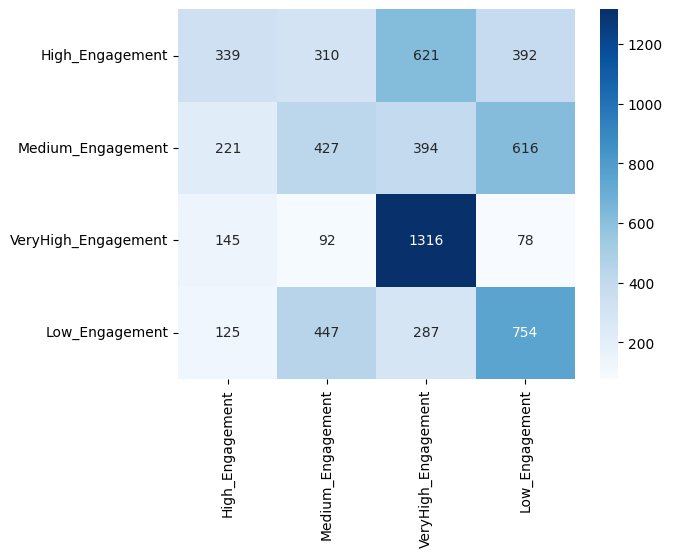

In [132]:
from collections import Counter
from sklearn.metrics import f1_score, classification_report, confusion_matrix

# --- 1. PREPARAZIONE ---
# X deve essere una lista di liste (transazioni)
target_classes = {"Low_Engagement", "Medium_Engagement", "High_Engagement", "VeryHigh_Engagement"}

x_train, x_test = train_test_split(X, test_size=0.3, random_state=0)

# Calcoliamo la Default Class (Majority Class)
train_labels = [next((item for item in rec if item in target_classes), None) for rec in x_train]
default_class = Counter(train_labels).most_common(1)[0][0]
print(f"Default Class: {default_class}")


# --- 2. MINING E PRUNING INTELLIGENTE ---
print("Esecuzione Apriori...")
# Usiamo zmin=2 per evitare regole vuote o banali
rules_raw = fpgrowth(x_train, target="r", supp=supp, zmin=2, conf=20, report="aScl") 

rules_df = pd.DataFrame(
    rules_raw,
    columns=["consequent", "antecedent", "abs_supp", "%_supp", "conf", "lift"]
)

# Filtriamo solo le regole che predicono il target
rules_df = rules_df[rules_df["consequent"].isin(target_classes) & (rules_df["lift"] > 1)]

# 1. Calcoliamo le Top per LIFT (Qualità)
top_lift = rules_df.sort_values(by="lift", ascending=False).groupby("consequent").head(50)

# 2. Calcoliamo le Top per SUPPORT (Quantità/Copertura)
top_supp = rules_df.sort_values(by="%_supp", ascending=False).groupby("consequent").head(50)

# 3. Uniamo i due set e rimuoviamo duplicati
# (Usiamo l'ID della regola o resettiamo l'indice per unire)
combined_rules = pd.concat([top_lift, top_supp]).drop_duplicates(subset=["consequent", "antecedent"])

print(f"Regole totali ibride: {len(combined_rules)}")


rules_pruned = combined_rules

voting_rules = []
for _, row in rules_pruned.iterrows():
    voting_rules.append({
        "consequent": row["consequent"],
        "antecedent": set(row["antecedent"]),
        "lift": row["lift"],   # Il "peso" del voto
        "conf": row["conf"]    # Alternativa: usare confidenza
    })

print(f"Regole usate per il voto: {len(voting_rules)}")

# --- 2. FUNZIONE DI PREDIZIONE (WEIGHTED VOTING) ---

def predict_voting(record, rules, default_class):
    record_set = set(record)
    
    # Inizializziamo i punteggi per ogni classe a 0
    # Assicurati che score_board contenga tutte le tue classi
    score_board = {cls: 0 for cls in target_classes}
    
    rules_triggered = 0
    
    for rule in rules:
        # Se la regola si applica al record
        if rule["antecedent"].issubset(record_set):
            # Aggiungiamo il Lift al punteggio della classe predetta
            # (Puoi provare anche rule["conf"] o rule["lift"] * rule["conf"])
            score_board[rule["consequent"]] += rule["lift"]
            rules_triggered += 1
            
    # Se nessuna regola si è attivata, usiamo il default
    if rules_triggered == 0:
        return default_class
    
    # Restituiamo la classe con il punteggio più alto
    return max(score_board, key=score_board.get)

# --- 3. VALUTAZIONE ---
correct = 0
total = 0
uncovered_count = 0

# --- LISTE PER SALVARE I RISULTATI ---
y_true = []
y_pred = []

# Variabili per statistiche interne (opzionale)
uncovered_count = 0 

print("Inizio predizione (Voting)...")

for record in x_test:
    # 1. Estrazione Ground Truth
    true_label = next((item for item in record if item in target_classes), None)
    
    # 2. Pulizia record per il test
    record_features = [item for item in record if item not in target_classes]
    
    if true_label:
        # Eseguiamo la predizione
        prediction = predict_voting(record_features, voting_rules, default_class)
        
        # Salviamo nelle liste per sklearn
        y_true.append(true_label)
        y_pred.append(prediction)
        
        # Controllo di copertura (se nessuna regola si è attivata)
        matches_any = any(rule["antecedent"].issubset(set(record_features)) for rule in voting_rules)
        if not matches_any:
            uncovered_count += 1

# --- CALCOLO METRICHE ---

# 1. F1 Score Globale (Weighted è meglio se le classi sono sbilanciate)
f1 = f1_score(y_true, y_pred, average='weighted')

print("-" * 30)
print(f"F1-Score (Weighted): {f1:.4f}")
print(f"Copertura Regole: {((len(y_true) - uncovered_count) / len(y_true))*100:.2f}%")

# 2. Report Dettagliato (F1 per ogni classe)
print("\n--- Classification Report ---")
print(classification_report(y_true, y_pred))

# 3. Matrice di Confusione (Opzionale ma utilissima per capire gli errori)
# Ti mostra se il modello confonde classi vicine (es. High vs VeryHigh)
cm = confusion_matrix(y_true, y_pred, labels=list(target_classes))
print("\n--- Confusion Matrix ---")
#heatmap per visualizzare meglio
sns.heatmap(cm, annot=True, fmt='d', xticklabels=target_classes, yticklabels=target_classes, cmap='Blues')
print(cm)